# Customers Bank Churn Prediction Using `XGBoost`

### Libraries

In [48]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score , classification_report, roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt


In [4]:
import warnings
warnings.filterwarnings('ignore')

### Import Clean Dataset

In [5]:
df = pd.read_csv('BankCustomersSet_XGBoost.csv', sep = ',')
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn,Geography_Germany,Geography_Spain
0,619,0,42,2,0,1,1,1,101348,1,0,0
1,608,0,41,1,83807,1,0,1,112542,0,0,1
2,502,0,42,8,159660,3,1,0,113931,1,0,0
3,699,0,39,1,0,2,0,0,93826,0,0,0
4,850,0,43,2,125510,1,1,1,79084,0,0,1


In [6]:
df.info() 
# All features are numeric

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CreditScore        10000 non-null  int64
 1   Gender             10000 non-null  int64
 2   Age                10000 non-null  int64
 3   Tenure             10000 non-null  int64
 4   Balance            10000 non-null  int64
 5   NumOfProducts      10000 non-null  int64
 6   HasCrCard          10000 non-null  int64
 7   IsActiveMember     10000 non-null  int64
 8   EstimatedSalary    10000 non-null  int64
 9   Churn              10000 non-null  int64
 10  Geography_Germany  10000 non-null  int64
 11  Geography_Spain    10000 non-null  int64
dtypes: int64(12)
memory usage: 937.6 KB


### Train Test Split

In [7]:
X = df.drop('Churn', axis = 1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size : {X_train.shape[0]} | Test size : {X_test.shape[0]}")
print(f"Churn rate train : {y_train.mean():.2%} | Churn rate test : {y_test.mean():.2%}")
#slide note : KFold CV
# 20% Validation, 10% test, 70% train
# Only if CV : split = 90% train, 10% test
# Split Kflod CV
# Training check
# How does it perfom on not seen data ? Validation set
# Change hyperparameters (same one for the 5 folds) of the model, retrain, check again on validation set
# Metrics : accurancy, prevision, recall, f1-score
# Once I'm happy
# Test dataset : final evaluation. No more change to not overfit. Well = test metrics similar to validation
# If test metrics are much worse than validation : overfitting
#Train final model on all data. No evaluation 
#Prediction on new data .predict

Train size : 8000 | Test size : 2000
Churn rate train : 20.38% | Churn rate test : 20.35%


In [8]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8000, 11) (2000, 11) (8000,) (2000,)


In [9]:
churn_rate = y.value_counts(normalize=True)
print(churn_rate)
# Churn = 1 -> 20%, we will have to adjust with scale_pos_weight

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight calculé : {scale_pos_weight:.1f}")

Churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64
scale_pos_weight calculé : 3.9


### Build the `XGBoost`Model

#### Hyperparameters tuning

In [17]:
# Fix parameters 

base_params = {
    'objective' : 'binary:logistic',
    'eval_metric' :'logloss',
    'scale_pos_weight' : round(scale_pos_weight, 1),
    'random_state' : 42
}

In [15]:
param_grid1 = {
    'max_depth': [2, 4, 6],
    'min_child_weight': [5, 8, 10],
    'gamma': [0, 0.3, 0.5],
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_lambda' : [1, 1.5],
    'reg_alpha' :  [0, 0.5]
}

#### Training - Cross Validation

In [26]:
fbeta = make_scorer(fbeta_score, beta=2, average='binary')

model_1 = XGBClassifier(**base_params)
grid_cv1 = GridSearchCV(model_1, param_grid1, cv=5, n_jobs=-1, scoring = fbeta)
grid_cv1.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'gamma': [0, 0.3, ...], 'learning_rate': [0.1, 0.2], 'max_depth': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...verage=binary)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [36]:
print("The Best Parameters :", grid_cv1.best_params_)
print("Best Fbeta Score :", grid_cv1.best_score_)

The Best Parameters : {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 8, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 1, 'subsample': 0.8}
Best Fbeta Score : 0.6912196123896492


#### Baseline Evaluation  
To assess the relevance of our XGBoost model, we compared its performance against a **stratified dummy classifier**, which predicts churn randomly while respecting the class distribution.

In [30]:
dummy = DummyClassifier(strategy= 'stratified')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

fbeta_dummy = fbeta_score(y_test, y_pred_dummy, beta=2, average='binary')
print(f"Baseline F-beta : {fbeta_dummy:.4f}")

Baseline F-beta : 0.1846


| Model | F-beta Score (β=2) |
|---|---|
| Dummy Classifier (baseline) | 0.1846 |
| XGBoost | 0.69 |

The XGBoost model achieves a score **4x higher than the baseline**, demonstrating that the model has genuinely learned patterns from the data rather than simply exploiting class distribution.

#### Hyperparameters adjusted

In [ ]:
param_grid2 = {
    'max_depth': [3, 4, 5],
    'min_child_weight': [7, 8, 9],
    'gamma': [0.3, 0.5, 0.7],
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_lambda' : [0.8, 1],
    'reg_alpha' :  [0.5, 0.8]
}

In [32]:
model_2 = XGBClassifier(**base_params)
grid_cv2 = GridSearchCV(model_2, param_grid2, cv=5, n_jobs=-1, scoring = fbeta)
grid_cv2.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'gamma': [0.3, 0.5, ...], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...verage=binary)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [35]:
print("The Best Parameters :", grid_cv2.best_params_)
print("Best Fbeta Score :", grid_cv2.best_score_)

The Best Parameters : {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 7, 'n_estimators': 200, 'reg_alpha': 0.8, 'reg_lambda': 1, 'subsample': 0.8}
Best Fbeta Score : 0.6950275368535086


In [37]:
param_grid3 = {
    'max_depth': [2, 3, 4],
    'min_child_weight': [6, 7, 8],
    'gamma': [0.5],
    'n_estimators': [200, 500],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_lambda' : [1],
    'reg_alpha' :  [0.8, 1]
}

In [38]:
model_3 = XGBClassifier(**base_params)
grid_cv3 = GridSearchCV(model_3, param_grid3, cv=5, n_jobs=-1, scoring = fbeta)
grid_cv3.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'gamma': [0.5], 'learning_rate': [0.01, 0.05], 'max_depth': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...verage=binary)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [40]:
print("The Best Parameters :", grid_cv3.best_params_)
print("Best Fbeta Score :", grid_cv3.best_score_)

best_param3 = grid_cv3.best_params_

The Best Parameters : {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 7, 'n_estimators': 200, 'reg_alpha': 0.8, 'reg_lambda': 1, 'subsample': 0.8}
Best Fbeta Score : 0.6950275368535086


| Model | Best F-beta Score (β=2) |
|---|---|
| Model 1 | 0.6912 |
| Model 2 | 0.6950 |
| Model 3 | 0.6950 |

After 3 successive iterations of `GridSearchCV`, the optimization process has converged. 
Model 3 returned **identical parameters and score** to Model 2, confirming that further grid search iterations are unlikely to yield meaningful improvements within this hyperparameter space.


### Test step

In [43]:
final_params = {
    **base_params,
    **best_param3
}

In [44]:
final_model = XGBClassifier(**final_params)
final_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Model Evaluation

In [46]:
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Average Precision : {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"F-beta (β=2)      : {fbeta_score(y_test, y_pred, beta=2, average='binary'):.4f}")

              precision    recall  f1-score   support

   Non-Churn       0.93      0.81      0.87      1593
       Churn       0.51      0.77      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.85      0.80      0.81      2000

ROC-AUC : 0.8688
Average Precision : 0.7172
F-beta (β=2)      : 0.6965


**ROC-AUC at 0.8688** indicates that the model correctly ranks a churner above a non-churner 87% of the time. This confirms strong discriminative power regardless of the classification threshold.

**Average Precision at 0.7172** summarizes the precision-recall tradeoff across all thresholds. In an imbalanced setting (20% churners), this is a robust result — a random model would score around 0.20.

**F-beta (β=2) at 0.6965** reflects the model's ability to detect churners while accepting some false alarms. The β=2 weighting prioritizes recall over precision, consistent with the business objective of minimizing missed churners.

> The final F-beta score on the test set (0.6965) is virtually identical to the cross-validation score (0.6950), confirming that the model generalizes well and shows no signs of overfitting.

**Non-Churn Class (class 0)**  
Precision 0.94 → when it predicts ‘non-churn’, it is correct 94% of the time ✅  
Recall 0.81 → it detects 81% of true non-churners ✅  

**Churn class (class 1)**  
Recall 0.80 → the model detects 80% of true churners ✅ this is its strong point  
Precision 0.51 → but among customers predicted to churn, only 51% actually do ⚠️

**The real problem: too many false alarms**  
The model is too aggressive - it prefers to over classify churn so as not to miss any. 
As a result, for every two real churners detected, it generates almost one false alarm.

#### Option 1 — Raise the decision threshold

In [53]:
threshold = 0.6
y_pred_custom = (y_pred_proba >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom, target_names=['Non-Churn', 'Churn']))
print(f"ROC-AUC           : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Average Precision : {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"F-beta (β=2)      : {fbeta_score(y_test, y_pred_custom, beta=2, average='binary'):.4f}")

              precision    recall  f1-score   support

   Non-Churn       0.91      0.89      0.90      1593
       Churn       0.60      0.67      0.64       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000

ROC-AUC           : 0.8688
Average Precision : 0.7172
F-beta (β=2)      : 0.6577


#### Option 2 - Optimal threshold via Precision-Recall Curve

Optimal Threshold (F-beta) : 0.3406
Precision at this threshold : 0.3843
Recall at this threshold    : 0.8894
F-beta at this threshold    : 0.7043


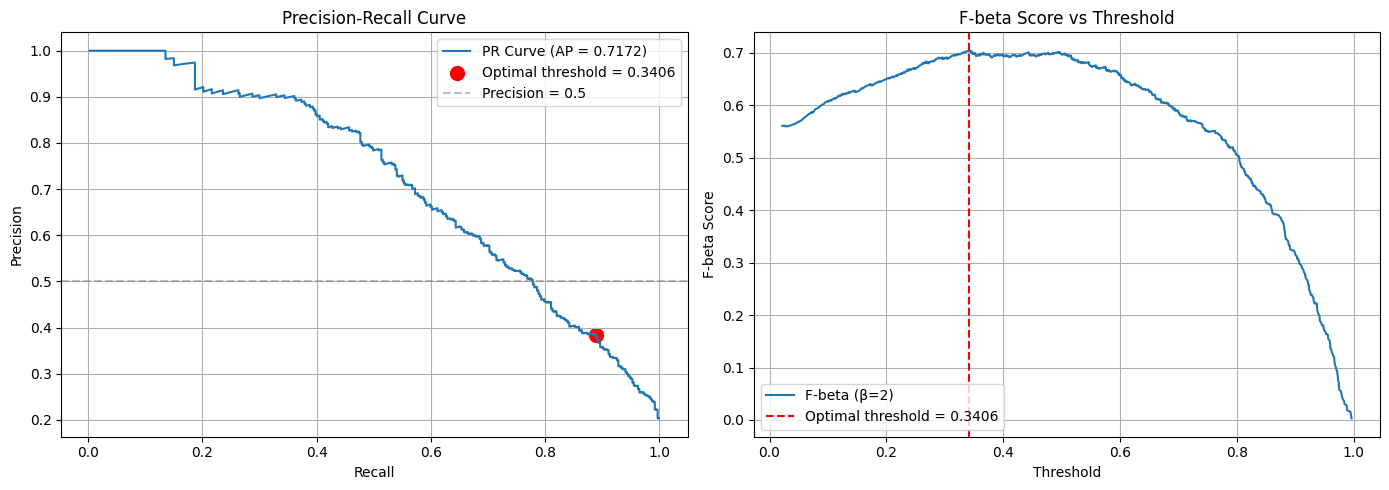

              precision    recall  f1-score   support

   Non-Churn       0.96      0.64      0.76      1593
       Churn       0.38      0.89      0.54       407

    accuracy                           0.69      2000
   macro avg       0.67      0.76      0.65      2000
weighted avg       0.84      0.69      0.72      2000

F-beta (β=2) : 0.7043


In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Maximize F-beta (β=2) across all thresholds
beta = 2
fbeta_scores = (1 + beta**2) * (precision[:-1] * recall[:-1]) / (beta**2 * precision[:-1] + recall[:-1])
optimal_idx = np.argmax(fbeta_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (F-beta) : {optimal_threshold:.4f}")
print(f"Precision at this threshold : {precision[optimal_idx]:.4f}")
print(f"Recall at this threshold    : {recall[optimal_idx]:.4f}")
print(f"F-beta at this threshold    : {fbeta_scores[optimal_idx]:.4f}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curve
axes[0].plot(recall[:-1], precision[:-1], label=f'PR Curve (AP = {average_precision_score(y_test, y_pred_proba):.4f})')
axes[0].scatter(recall[optimal_idx], precision[optimal_idx], color='red', s=100,
                label=f'Optimal threshold = {optimal_threshold:.4f}')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Precision = 0.5')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True)

# F-beta Score vs Threshold
axes[1].plot(thresholds, fbeta_scores, label='F-beta (β=2)')
axes[1].axvline(optimal_threshold, color='red', linestyle='--',
                label=f'Optimal threshold = {optimal_threshold:.4f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F-beta Score')
axes[1].set_title('F-beta Score vs Threshold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# --- Apply optimal threshold ---
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal, target_names=['Non-Churn', 'Churn']))
print(f"F-beta (β=2) : {fbeta_score(y_test, y_pred_optimal, beta=2, average='binary'):.4f}")

In [52]:
threshold = 0.3406
y_pred_custom = (y_pred_proba >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom, target_names=['Non-Churn', 'Churn']))
print(f"ROC-AUC           : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Average Precision : {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"F-beta (β=2)      : {fbeta_score(y_test, y_pred_custom, beta=2, average='binary'):.4f}")

              precision    recall  f1-score   support

   Non-Churn       0.96      0.64      0.76      1593
       Churn       0.38      0.89      0.54       407

    accuracy                           0.69      2000
   macro avg       0.67      0.76      0.65      2000
weighted avg       0.84      0.69      0.72      2000

ROC-AUC           : 0.8688
Average Precision : 0.7172
F-beta (β=2)      : 0.7026


#### Comparison across thresholds

| Metric | Threshold 0.34 | Threshold 0.50 | Threshold 0.60 |
|---|---|---|---|
| Precision (Churn) | 0.38 | 0.51 | 0.60 |
| Recall (Churn) | 0.89 | 0.77 | 0.67 |
| F-beta (β=2) | 0.7043 | 0.6965 | 0.6577 |

#### Threshold 0.3406 — Maximize Recall
With a low threshold, the model is **aggressive** in flagging churners. It catches **89% of actual churners** (361 out of 407), at the cost of a lower precision (0.38) — meaning roughly 6 out of 10 churn alerts are false alarms. This threshold is optimal when retention actions are **cheap** (automated emails, push notifications), where the cost of missing a churner far outweighs the cost of a false alarm.

#### Threshold 0.60 — Maximize Precision
With a higher threshold, the model is **conservative**, only flagging customers when confidence is high. Precision rises to 0.60 but recall drops to 0.67 — the model now misses **1 in 3 churners**. This threshold makes sense when retention actions are **expensive** (commercial calls, personalized discounts), where acting on false alarms has a significant cost.

---

#### The real question is not which model has the best F-beta

A high F-beta score does not automatically make a model the best choice for deployment. **The best model is the one that minimizes real business cost.**

The true optimization problem is:
```
Total Cost = (Missed Churners × Cost of losing a customer)
           + (False Alarms   × Cost of unnecessary retention action)
```

> 🎯 **Key takeaway:** The threshold is not a modeling decision — it is a business decision. The data scientist's role is to surface the tradeoffs clearly; the business decides where to draw the line.